# Compas Analysis - Nicholas Botti - Python Version

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [74]:
#If needed: Install packages
!pip install pandas numpy matplotlib scikit-learn lifelines

In [75]:
import pandas as pd

#Load the data
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)

In [76]:
#Look at the first 10 obversations of the data
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [77]:
#The variables involved are selected and categorized
numeric_vars = ["age", "priors_count", "days_b_screening_arrest",
                   "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

selected_data = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text',
                          'sex', 'priors_count', 'days_b_screening_arrest',
                          'decile_score', 'is_recid', 'two_year_recid',
                          'c_jail_in', 'c_jail_out']]
# ── Filtering ────────────────────────────────────────────────────
selected_data = selected_data[(selected_data['days_b_screening_arrest'] >= -30) & (selected_data['days_b_screening_arrest'] <= 30)]
selected_data= selected_data[selected_data['is_recid'] != -1]
selected_data = selected_data[selected_data['c_charge_degree'] != '0']
selected_data = selected_data[selected_data['score_text'] != 'N/A']

# ── Type conversions ─────────────────────────────────────────────
for col in datetime_vars:
    selected_data[col] = pd.to_datetime(selected_data[col], format="%Y-%m-%d %H:%M:%S", utc=True)
#and...
for col in selected_data.columns:
    if col not in numeric_vars and col not in datetime_vars:
        selected_data[col] = selected_data[col].astype('category')
# ── Derived factors with reference levels ─────────────────────────
selected_data["crime_factor"] = selected_data["c_charge_degree"].astype("category")

selected_data["age_factor"] = pd.Categorical(selected_data["age_cat"], categories=["25 - 45", "Less than 25", "Greater than 45"], ordered=False)

selected_data["race_factor"] = pd.Categorical(selected_data["race"], categories=["Caucasian", "African-American", "Other"], ordered=False)

selected_data["gender_factor"] = pd.Categorical(selected_data["sex"], categories=["Male", "Female"])

selected_data["score_factor"] = pd.Categorical(
    selected_data["score_text"] != "Low",
    categories=[False, True]
).rename_categories(["LowScore", "HighScore"])

#Check number of observations after these commands
len(selected_data)


6172

In [78]:
#See the first 10 observations of the selected_data, the dataframe after manipulating a lot of the data.
selected_data.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [79]:
#Look at the type of data each column is, the name of the column, and other conditions acceptable data in each column has
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Below, we calculate and find that higher COMPAS scores are slightly correlated with a longer length of stay. This positive correlation suggests that individuals with higher COMPAS scores tend to have longer stays, though this may reflect judicial decisions or systemic factors rather than a causal relationship.

In [80]:
#Calculating the length of the stay using the jail in time and jail out time, focusing on the days from that data
selected_data["length_of_stay"] = (pd.to_datetime(selected_data["c_jail_out"]) - pd.to_datetime(selected_data["c_jail_in"])).dt.days
#Calculating the correlation
correlation = selected_data['length_of_stay'].corr(selected_data['decile_score'])
print(correlation)

0.20747808478031807


After filtering we have the following demographic breakdown:

The age distribution shows that the majority of observations (3,532) fall between ages 25–45, with fewer individuals under 25 (1,347) and over 45 (1,293). This imbalance means that younger and older individuals outside of the 25-45 age group are underrepresented, limiting the model’s ability to accurately learn patterns for those age groups.

In [81]:
#See how many observations are allocated to different age categories
selected_data["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


Below, we see that 3,175 observations identify as African-American, 2,103 are Caucasian, 509 are Hispanic, 343 are Other, 31 are Asian, and 11 are Native American.

In [82]:
#See how many observations are allocated to different age categories
selected_data["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


We observe that over half of the observations are Black defendants, while 34% are White defendants, suggesting that Black individuals may be overrepresented in the dataset. This imbalance raises concerns about (and could contribute to) potential bias in the COMPAS model, as it may be trained on data that reflect systemic patterns in arrests (like targeted policing in certain neighborhoods) rather than underlying criminal behavior. Additionally, the data may not fully account for socioeconomic factors or historical inequalities, which can further bias risk predictions.

In [83]:
#Using the counts above, figure out the percentage of the observations that are Black defendants, White defendants, Hispanic defendants, Asian defendants, and Native American defendants
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


Below it is seen that 3,421 of the observations have a low COMPAS score, 1,607 have a medium COMPAS score, and 1,144 have a high COMPAS score. We see that the model tends to assign lower COMPAS scores to most defendants, which indicate low-risk. Conversely, only fewer are categoried with a high COMPAS score, indicating high-risk. If the model is trained on this, it makes it so that predictions for high-risk individuals are based on a smaller sample, which could reduce reliability and increase variability in that group.

In [84]:
#See the counts of the observations allocated across risk scores - Low, Medium, and High
selected_data["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


Next, the value counts between race and sex are examined to see the composite of the demographic data that is in this dataset. We see that majority of the dataset is comprised of African-American males. On top of this, there are overwhelmingly more males than female in the data given. This indicates a demographic imbalance. This imbalance can be a factor that brings bias into the model, as it is trained primarily on African-American Males, potentially limiting its ability to generalize accurately to underrepresented groups, particularly females and non–African-American individuals.

In [85]:
#Construct a crosstab that shows the allocation of observations between sex and race
pd.crosstab(selected_data['sex'], selected_data['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


The data also has significantly more males than female in the dataset. As a result, the model may be trained on males, but when needing to generalize to females, could not be as accurate.

In [86]:
#See the distribution of the observations across sex - Male and Female
selected_data["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


Percentage wise, 80.96% of the dataset are males, whereas 19.04% are females, further strengthening the point that males are overrepresented in the data, and could cause biases for the model as it trains.

In [87]:
#Print neatly the percentages of the sex represented in the data
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


Below shows how many people were reoffended within 2 years, which can be used to get the base rate of recidivism (next line of code). This is important when evaluating the model performance and identifying potential imbalances.

In [88]:
#Show how many observations were reoffended within 2 years
len(selected_data[selected_data["two_year_recid"] == 1])

2809

We see that the base rate of recidivism is 45.51%. This is the percentage of people actually reoffended (within 2 years). The nearly half of the sample reoffending is a key baseline for evaluating how useful COMPAS predictions are.

In [89]:
#Divide the number of obersations that were reoffended within 2 years by the total amount of observations to get the rate
len(selected_data[selected_data["two_year_recid"] == 1]) / len(selected_data) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants. Conversely, there is not a clear trend in the decile scores as those scores increase for black defendants. This means that the COMPAS decile scores may be more consistent and predictive of recidivism for White defendants, but not as consistent and predictive for Black defendants (because higher scores don't correspond to higher observed risk). This raises concerns about the fairness of the risk scores.

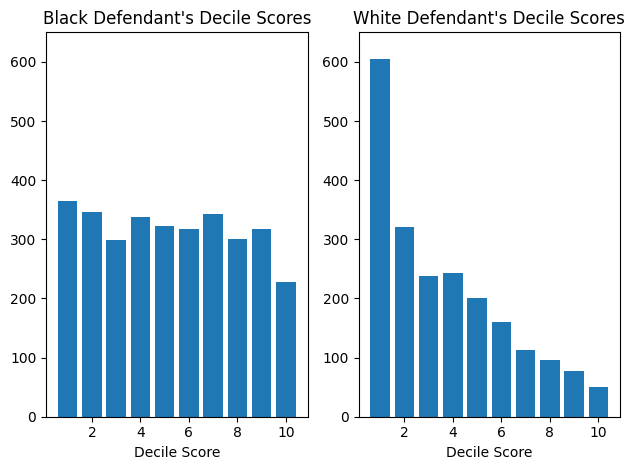

In [90]:
import matplotlib.pyplot as plt

# Filter the data, splitting it into Black and White defendants
black = selected_data[selected_data["race"] == "African-American"]
white = selected_data[selected_data["race"] == "Caucasian"]

# Count how many people fall into each decile score for each group
black_counts = black["decile_score"].value_counts().sort_index()
white_counts = white["decile_score"].value_counts().sort_index()

# Create two charts side by side
fig, axes = plt.subplots(1, 2)

# Left chart: Black defendants
# Shows how COMPAS scores are distributed for this group
axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# Right chart: White defendants
# Shows how COMPAS scores are distributed for this group
axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

To see the distribution of all observations across each race category in the dataset, a crosstab was creating. While it's difficult to interpret the results based on the table, we can see that African Americans face less of a downward trend as decile scores increase, supporting the conclusion above and raising concerns about fairness.

In [91]:
#Create a crosstab table with decile-score (1-10) and race (African-American, Asian, Caucasian, Hispanic, Native American, and Other)
pd.crosstab(selected_data['decile_score'], selected_data['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

The positive and statistically significant coefficient for African-American defendants indicates that, holding other factors constant (such as age, prior offenses, gender, and recidivism), African-American individuals have higher odds of being classified as high risk compared to the reference group (White defendants).

In [92]:
import pandas as pd
import statsmodels.api as sm

df = selected_data.copy()

# Convert to categorical
df['crime_factor'] = df['c_charge_degree'].astype('category')
df['age_factor'] = df['age_cat'].astype('category')
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)
df['gender_factor'] = pd.Categorical(
    df['sex'],
    categories=['Male', 'Female'],
    ordered=False
)

# Create target variable
df['score_factor'] = (df['score_text'] != "Low").astype(int)   # 1 = HighScore, 0 = LowScore

# Create design matrix
X = pd.get_dummies(
    df[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']],
    drop_first=True
)

# Convert booleans to ints if needed
X = X.astype(int)

y = df['score_factor']

# Add intercept
X_sm = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X_sm)
result = model.fit()

# Full summary
print(result.summary())

# Coefficients + p-values table
summary_df = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues
})

print(summary_df)

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        23:41:42   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.5255      0.079    -19.430      0.000

After calculating the probability from the coefficients of the logistic regresison, we see that Black defendants are 45% more likely than White defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [93]:
import numpy as np

# Calculate the baseline probability (control)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# Calculate probability using the African-American coefficient
answer = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

print(answer)

1.4528408658138932


Additionally, we see that Women are 19.4% more likely than men to get a higher score. This suggests that gender could play a role in the model's risk classification, but not as significant as the other disparities that have been pointing out so far.

In [94]:
#Calculate the probability using the Women coefficient
answer = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))
print(answer)

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants. This suggests that younger individual are perceived as higher risk, which could be due higher recidivism among younger populations.

In [95]:
#Calculate the probaility using the Less than 25 coefficient
answer = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))
print(answer)

2.4961202077189455


### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [96]:
import pandas as pd

#Read in the new data file and see how many observations the data has
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv'
violent_df = pd.read_csv(url)
len(violent_df)

4743

In [97]:
#Select the columns necessary for the logistic regression that will test for racial bias
selected_data = violent_df[['age', 'c_charge_degree', 'race', 'age_cat', 'v_score_text',
                          'sex', 'priors_count', 'days_b_screening_arrest',
                          'v_decile_score', 'is_recid', 'two_year_recid']]
# ── Filtering ────────────────────────────────────────────────────
selected_data = selected_data[(selected_data['days_b_screening_arrest'] >= -30) & (selected_data['days_b_screening_arrest'] <= 30)]
selected_data= selected_data[selected_data['is_recid'] != -1]
selected_data = selected_data[selected_data['c_charge_degree'] != '0']
selected_data = selected_data[selected_data['v_score_text'] != 'N/A']
len(selected_data)

4020

When looking at the composition of age below in this dataset, it is evident that 25-45 are majority of the data, indicating overrepresentation and bias.

In [98]:
#Show the distribution of observations in age among three categories: 25-45, Greater than 45, and Less than 25
selected_data["age_cat"].value_counts()

,count
age_cat,
25 - 45,2300
Greater than 45,954
Less than 25,766


Next, we see that majority of the observations are African-American in this dataset.

In [99]:
#Show the distribution of observations in race
selected_data["race"].value_counts()

,count
race,
African-American,1918
Caucasian,1459
Hispanic,355
Other,255
Asian,26
Native American,7


The scores that aim to measure a persons risk of violent recidivism is Low for majority of the observations in this dataset. While individuals are posing a relatively low risk of committing a violent offense in the future in this dataset, the imbalance can mean that there are less medium and high-risk cases to train on, which makes it more difficult for the model to accurately distinguish truly high-risk individuals.

In [100]:
#Show the distribution of observations based on the v-score text
selected_data["v_score_text"].value_counts()

,count
v_score_text,
Low,2913
Medium,828
High,279


We see that the base rate of recidivism has been reduced to 16.22% in the case of the violent scores data. This is the percentage of people actually reoffended (within 2 years), and indicates that violent recidivism is much less common than general recidivism. This can make the model preiction more difficult, as the model is identifying a small group of true reoffenders, reducing accuracy.

In [101]:
#Divide the number of observations of true offenders by the total amount of observations in the data
len(selected_data[selected_data["two_year_recid"] == 1]) / len(selected_data) * 100

16.218905472636816

In total, 652 observations were reoffended within 2 years, quantifying the small sample of true reoffenders.

In [102]:
#Show the number of observations of true offenders
len(selected_data[selected_data['two_year_recid'] == 1])

652

To get a solid understanding of the relationship (and assignment) of violent decile scores between Black and White defendants, a bar chart was created, with the x-axis being the increasing violent decile score, and the y-axis being the counts of each score in the data. In comparison to the general decile scores analyzed earlier in the notebook, Black defendants see a steeper downward trend in count as violent decile scores increase, matching more of what the White defendants distribution looks like. However, it is still clear that White defendants receive lower deciles scores than Black defendants. There is a steep drop off of violent decile scores in the White defendant chart, going from score 1 to 2. This suggests that, even in the context of violent recidivism where overall risk is lower, Black defendants may still be disproportionately assigned higher risk scores, raising concerns about potential bias in how the model evaluates risk across racial groups.

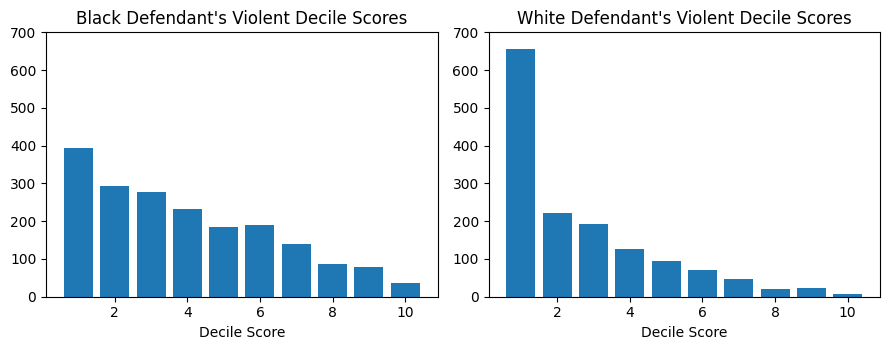

In [103]:
import matplotlib.pyplot as plt

#Filter the data, splitting it into Black and White defendants
black = selected_data[selected_data["race"] == "African-American"]
white = selected_data[selected_data["race"] == "Caucasian"]

#Count how many people fall into each decile score for each group
black_counts = black["v_decile_score"].value_counts().sort_index()
white_counts = white["v_decile_score"].value_counts().sort_index()

#Create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

#Left Chart: Black defendants
#Shows how COMPAS scores are distributed for this group
axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 700)

#Right Chart: White defendants
#Shows how COMPAS scores are distributed for this group
axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

By building a logistic regression, we can gather statistical findings that signify the significance of the biases that the model may show after being trained on this particular data.

The coefficient for African-American defendants is positive (0.659) and statistically significant (p < 0.001), meaning they have about 93% higher odds of receiving a high violent risk score compared to White defendants, holding other factors constant. Compared to the general logistic regression earlier, the affect of race is stronger, suggesting that it plays an bigger role in how violent risk scores are assigned.

In [104]:
import pandas as pd
import statsmodels.api as sm

df = selected_data.copy()

# Convert to categorical
df['crime_factor'] = df['c_charge_degree'].astype('category')
df['age_factor'] = df['age_cat'].astype('category')
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)
df['gender_factor'] = pd.Categorical(
    df['sex'],
    categories=['Male', 'Female'],
    ordered=False
)

# Create target variable
df['v_score_factor'] = (df['v_score_text'] != "Low").astype(int)   # 1 = HighScore, 0 = LowScore

# Create design matrix
X = pd.get_dummies(
    df[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'two_year_recid']],
    drop_first=True
)

# Convert booleans to ints if needed
X = X.astype(int)

y = df['v_score_factor']

# Add intercept
X_sm = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X_sm)
result = model.fit()

# Full summary
print(result.summary())

# Coefficients + p-values table
summary_df = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues
})

print(summary_df)

Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         v_score_factor   No. Observations:                 4020
Model:                          Logit   Df Residuals:                     4008
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.3662
Time:                        23:41:46   Log-Likelihood:                -1499.4
converged:                       True   LL-Null:                       -2365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.2427      0.113    -19.802      0.000

To put it simply, probabilities were calculated to show that Black defendants have significantly higher likelihood of being assigned a high violent risk score compared to White defendants. This suggests that, even when controlling for other factors, race is associated with higher predicted risk, raising concerns about potential bias in how the scores are assigned.

In [105]:
import numpy as np
# Calculate the baseline probability (control)
control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
# Calculate probability using the African-American coefficient
answer = np.exp(0.65893) / (1 - control + (control * np.exp(0.65893)))
print(answer)

1.7739209589164604


Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants. This shows that age plays a very strong role in the model, with younger individuals being viewed as significantly higher risk, even more so than in the general COMPAS model.

In [106]:
# Calculate probability using the Less than 25 coefficient
answer = np.exp(3.14591) / (1 - control + (control * np.exp(3.14591)))
print(answer)

7.414239863565466


## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [107]:
import pandas as pd

# Load the cox-parsed COMPAS dataset from the link
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv'
data = pd.read_csv(url)

# Remove rows where score is missing, and keep rows where end > start
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

# Turn race into a categorical variable, which Caucasian as the reference group
data["race_factor"] = pd.Categorical(
    data["race"],
    categories=["Caucasian","African-American", "Asian", "Hispanic", "Native American", "Other"])

# Turn score text into a categorical variable
data["score_factor"] = pd.Categorical(data["score_text"])

# Drop any duplicates in the data
grp = data.drop_duplicates(subset="id")

# Print how many unique people are in the dataset
print(len(grp))

10325


Now that the data has been loaded, looking at the distribution of observations between different categories will give us descriptive results to identify what proportions of the observations identify with different scores and races.

First, we see that in this particular data, more Low scores are assigned to different observations than the Medium or High, suggesting that the COMPAS model tends to classify most individuals as lower risk overall.

Secondly, in this dataset, we see that the majority of the observations are African-American (5,150), followed by Caucasian (3,576). This shows a noticeable imbalance in the data, where African-American defendants are more represented than other groups.

In [108]:
#Show the distribution of observations by score
grp["score_factor"].value_counts()

,count
score_factor,
Low,5751
Medium,2611
High,1952


In [109]:
#Show the distribution of observations by race
grp["race_factor"].value_counts()

,count
race_factor,
African-American,5150
Caucasian,3576
Hispanic,944
Other,572
Asian,51
Native American,32


Next, a Cox Proportional Hazards Model must be built to test whether COMPAS scores do a good job of assigning risk to an offender.

In [110]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
df = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
df = df[['start', 'end', 'event', 'score_factor']]

# Turn score into a categorical variable
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert score categories into dummy variables for the model
df = pd.get_dummies(df, columns=['score_factor'], drop_first=True)

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
cph.fit(df, duration_col='end', event_col='event', entry_col='start')

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30305.85
         time fit was run = 2026-03-28 23:41:48 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.78

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 19.53 <0.005    279.75
score_factor_High      0.00 30.14 <0.005    660.70
---
Concordance = 0.60
Partial AIC = 60615.71
log-likelihood ratio test = 942.82 on 2 df
-log2(p) of ll-ratio test = 680.10

As shown in the outputs above, people placed in the High category are 3.5 times as likely to recidivate (showing that COMPAS score is capturing some level of risk), and the COMPAS system's concordance 60%. This is lower than the accuracy quoted in the Northpoint study of 68%. This suggests that the model may not perform as well on this dataset and that the predictive ability is limited than what was originally claimed.

In [111]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
df = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
df = df[['start', 'end', 'event', 'decile_score']]

# Make sure decile_score is numeric
df['decile_score'] = pd.to_numeric(df['decile_score'], errors='coerce')

# Drop any rows with missing values in key columns
df = df.dropna(subset=['start', 'end', 'event', 'decile_score'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
cph.fit(df, duration_col='end', event_col='event', entry_col='start')

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30221.49
         time fit was run = 2026-03-28 23:41:58 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.61 <0.005    820.06
---
Concordance = 0.62
Partial AIC = 60444.98
log-likelihood ratio test = 1111.55 on 1 df
-log2(p) of ll-ratio test = 807.20

COMPAS's decile scores are a bit more accurate at 62%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [112]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
df = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

# Select columns we need for the model
df = df[['start', 'end', 'event', 'race_factor', 'score_factor']]

# Set reference group for race_factor
df['race_factor'] = pd.Categorical(
    df['race_factor'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

# Set reference group for score_factor
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop rows with missing values in key columns
df = df.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model with interaction between race and score
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30280.41
         time fit was run = 2026-03-28 23:42:00 UTC

---
                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                               
race_factor[T.African-American]                         0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor[T.Asian]                                   -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor[T.Hispanic]                                -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor[T.Native American]                         -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor[T.Other]                                    0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor[T.Medium]                                  0.84      2.32      0.07            0.70            0.98                2.02                2.67
score_factor[T.High]                                    1.28      3.61      0.08            1.12            1.45                3.06                4.25
race_factor[T.African-American]:score_factor[T.Medium] -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
race_factor[T.Asian]:score_factor[T.Medium]             0.99      2.68      0.71           -0.41            2.38                0.67               10.80
race_factor[T.Hispanic]:score_factor[T.Medium]          0.07      1.07      0.16           -0.26            0.39                0.77                1.47
race_factor[T.Native American]:score_factor[T.Medium]   1.39      4.01      1.12           -0.81            3.59                0.45               36.07
race_factor[T.Other]:score_factor[T.Medium]            -0.33      0.72      0.23           -0.79            0.12                0.45                1.13
race_factor[T.African-American]:score_factor[T.High]   -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
race_factor[T.Asian]:score_factor[T.High]               1.32      3.73      0.77           -0.19            2.82                0.83               16.80
race_factor[T.Hispanic]:score_factor[T.High]           -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
race_factor[T.Native American]:score_factor[T.High]     1.96      7.07      1.08           -0.17            4.08                0.85               59.09
race_factor[T.Other]:score_factor[T.High]               0.41      1.51      0.26           -0.09            0.92                0.91                2.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  4.59 <0.005     17.75
race_factor[T.Asian]                                      0.00 -1.55   0.12      3.04
race_factor[T.Hispanic]                                   0.00 -0.66   0.51      0.97
race_factor[T.Native American]                            0.00 -1.25   0.21      2.25
race_factor[T.Other]                                      0.00  0.13   0.90      0.16
score_factor[T.Medium]                                    0.00 11.80 <0.005    104.36
scor

The interaction term shows a similar disparity as the logistic regression above.

High-risk white defendants are 3.61× more likely than low-risk white defendants, while high-risk Black defendants are about 2.99× more likely than low. This shows that higher COMPAS scores are linked to higher recidivism risk for both groups, but the jump from low to high is smaller for Black defendants. In other words, the increase in risk is more pronounced for white defendants, which could mean the score does a better job separating low vs. high risk for whites than it does for Blacks.

In [113]:
#We can see the Hazard scores for each combination of risk and race, relative to the Caucasian, Low Risk reference group.
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


Below is a Kaplan Meiser plot, with time on the x-axis (how long individuals are followed) and survival probability (the probability of not recidivating) on the y-axis. Three lines: low risk, medium risk, and high risk are shown, with low risk having the highest survival curve, and high risk having the lowest survival curve. To interpret the performance of the score, the curve should be well separated. High risk should be recidivating sooners and more often than low risk individuals.

Based on the output, the scores seems to be distinguishing between the risk levels well overall.

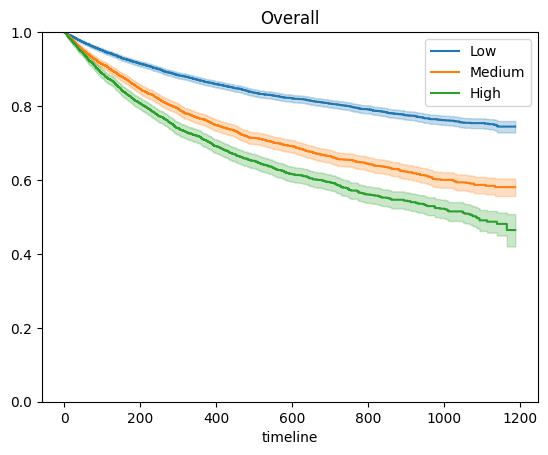

In [114]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

#Fit model
kmf = KaplanMeierFitter()

# Loop through each score group
for score in ["Low", "Medium", "High"]:
    subset = data[data["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ci_show=True)

# Add title and limits
plt.title("Overall")
plt.ylim(0, 1)

# Show plot
plt.show()

Black defendants do recidivate at higher rates according to race specific Kaplan Meier plots. This shows that while overall recidivism levels are higher for Black defendants, the increase in risk across COMPAS score is not as steep as it is for white defendants. This means that even though baseline risk seems to be higher, the score's ability to distinguish between low- and high-risk individuals may be weaker for Black defendants.

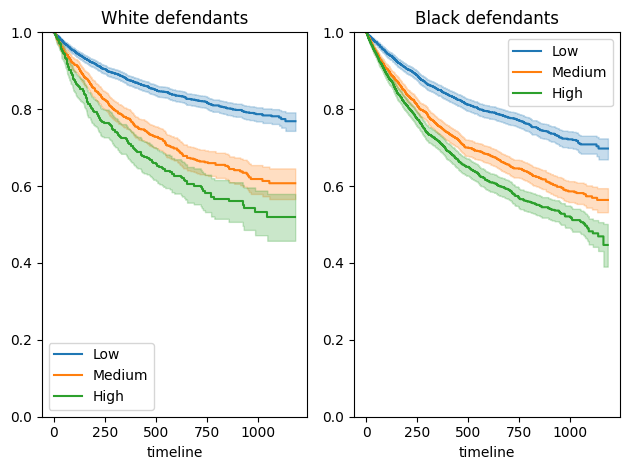

In [115]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = data[data["race"] == "Caucasian"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("White defendants")
axes[0].set_ylim(0, 1)

# Black chart
black = data[data["race"] == "African-American"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Black defendants")
axes[1].set_ylim(0, 1)

# Show plots
plt.tight_layout()
plt.show()

Below, the Kaplan Meiser survival curves are being fitted, and then, the estimated probability of not recidivating at time 730 are shown for each COMPAS risk group. The first code does this for the full sample, and then it is separately examined for the White defendants and Black defendants for comparison. The survival estimate, along with a 95% confidence level, are reported for this comparison.

The results show that survival decreases as risk level increases, with low-risk individuals having the highest survival and high-risk having the least, confirming the score is predictive. However, when you break it down by race, Black defendants have lower survival at every risk level, meaning that they are more likely to be reoffended across the board.

Additionally, the gap between low and high risk is larger for white defendants than for black defendants. This indicates that the score increases risk for both groups, but it differentiates more strongly for White defendants than for Black defendants.

In [116]:
# Create model
kmf = KaplanMeierFitter()

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = data[data["score_factor"] == score]

    # Fit survival curve
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = ci_730.iloc[0, 0]
    upper_730 = ci_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.8021577613594814
Lower 95% CI: 0.791747744020425
Upper 95% CI: 0.8121110234499288

Medium
Survival at 730: 0.6556909315249098
Lower 95% CI: 0.6376255074274386
Upper 95% CI: 0.6730996535819999

High
Survival at 730: 0.580821302329446
Lower 95% CI: 0.559145120078682
Upper 95% CI: 0.6018383488427669



In [117]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["race"] == "African-American"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7430101314698092
Lower 95% CI: 0.7234105111294775
Upper 95% CI: 0.7614582234057639

Medium
Survival at 730: 0.5484618451535137
Lower 95% CI: 0.5217058389977448
Upper 95% CI: 0.5743776469005313

High
Survival at 730: 0.3976132414748815
Lower 95% CI: 0.36969407026993195
Upper 95% CI: 0.4253690324189963



In [118]:
# Create model
kmf = KaplanMeierFitter()

# Filter to White defendants
white = data[data["race"] == "Caucasian"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = white[white["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7946073341971056
Lower 95% CI: 0.7770771557605307
Upper 95% CI: 0.8109312877713442

Medium
Survival at 730: 0.575683295727647
Lower 95% CI: 0.5384816958312129
Upper 95% CI: 0.611033739916427

High
Survival at 730: 0.43472948863102423
Lower 95% CI: 0.3810011895777014
Upper 95% CI: 0.4871685114025509



Race specific models have similar concordance values, with the white model at 60% and the Black model at 58%. The overall predictive performance of the Cox models is therefore nearly the same across both groups, and thus, the model can correctly rank individuals by risk across both groups.

In [119]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
df = white.copy()

# Select columns we need for the model
df = df[['start', 'end', 'event', 'score_factor']]

# Set score_factor as categorical with Low as reference group
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop any rows with missing values in key columns
df = df.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
# formula uses Low as the reference group
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4564 total observations, 3541 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 4564
number of events observed = 1023
   partial log-likelihood = -7919.63
         time fit was run = 2026-03-28 23:42:17 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  0.84      2.32      0.07            0.70            0.98                2.01                2.66
score_factor[T.High]    1.28      3.58      0.08            1.11            1.44                3.04                4.22

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.75 <0.005    103.54
score_factor[T.High]      0.00 15.26 <0.005    172.18
---
Concordance = 0.60
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56

In [120]:
from lifelines import CoxPHFitter
import pandas as pd

# Clean the data by removing missing scores and keeping valid time periods
df = black.copy()

# Select columns we need for the model
df = df[['start', 'end', 'event', 'score_factor']]

# Set score_factor as categorical with Low as reference group
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop any rows with missing values in key columns
df = df.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create the Cox proportional hazards model
cph = CoxPHFitter()

# Fit the model:
# start = entry time
# end = stop time
# event = whether recidivism happened
# formula uses Low as the reference group
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6862 total observations, 4827 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 6862
number of events observed = 2035
   partial log-likelihood = -16302.68
         time fit was run = 2026-03-28 23:42:19 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  0.67      1.95      0.06            0.56            0.78                1.75                2.18
score_factor[T.High]    1.10      2.99      0.05            0.99            1.20                2.69                3.33

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.89 <0.005    105.92
score_factor[T.High]      0.00 20.00 <0.005    293.26
---
Concordance = 0.58
Partial AIC = 32609.37
log-likelihood ratio test = 416.91 on 2 df
-log2(p) of ll-ratio test = 300.74

COMPAS’s violent recidivism score has a slightly higher overall concordance of 63%, indicating modest predictive accuracy. This is somewhat higher than the concordance observed in the separate models for Black and White defendants, suggesting the combined model performs slightly better overall, though accuracy remains limited.

In [121]:
from lifelines import CoxPHFitter
import pandas as pd

# Read the violent dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
violent_data = pd.read_csv(url)

# Keep rows with valid score_text
violent_data = violent_data[violent_data["score_text"] != "N/A"]

# Keep rows where end is greater than start
violent_data = violent_data[violent_data["end"] > violent_data["start"]]

# Create race_factor
violent_data["race_factor"] = pd.Categorical(
    violent_data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

# Create score_factor
violent_data["score_factor"] = pd.Categorical(
    violent_data["score_text"],
    categories=["Low", "Medium", "High"]
)

# Building the model
# Filter data
df = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person for CoxPHFitter
df = df.sort_values("end").drop_duplicates(subset="id", keep="last")

# Keep needed columns
df = df[['start', 'end', 'event', 'score_factor']]

# Set score categories
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop missing values
df = df.dropna(subset=['start', 'end', 'event', 'score_factor'])

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="score_factor"
)

# Keep one row per person
vgrp = violent_data.drop_duplicates(subset='id')

# Print number of people
print(len(vgrp))

# Show results
cph.print_summary()

10999


<lifelines.CoxPHFitter: fitted with 10985 total observations, 10167 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 10985
number of events observed = 818
   partial log-likelihood = -6968.34
         time fit was run = 2026-03-28 23:42:21 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.Medium]  1.00      2.73      0.09            0.83            1.17                2.30                3.23
score_factor[T.High]    1.77      5.90      0.08            1.61            1.94                5.00                6.96

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.Medium]    0.00 11.51 <0.005     99.46
score_factor[T.High]      0.00 21.04 <0.005    324.13
---
Concordance = 0.63
Partial AIC = 13940.67
log-likelihood ratio test = 431.64 on 2 df
-log2(p) of ll-ratio test = 311.36

In this case, there isn’t a significant coefficient on African Americans with High Scores, meaning their risk of violent recidivism is not statistically different from Caucasians with High Scores. The interaction term is essentially zero and insignificant, so a high COMPAS violent score increases risk similarly across both groups rather than disproportionately for African Americans.

In [122]:
from lifelines import CoxPHFitter
import pandas as pd

# Filter out invalid scores
df = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

df = df.sort_values("end").drop_duplicates(subset="id", keep="last")

# Keep only relevant columns for model
df = df[['start', 'end', 'event', 'race_factor', 'score_factor']]

# Set race_factor as categorical
df['race_factor'] = pd.Categorical(
    df['race_factor'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

# Set score_factor as categorical
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Drop missing values
df = df.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

# Initialize model
cph = CoxPHFitter()

# Fit model with race, score, and interaction
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Display model results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10985 total observations, 10167 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 10985
number of events observed = 818
   partial log-likelihood = -6951.94
         time fit was run = 2026-03-28 23:42:24 UTC

---
                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                
race_factor[T.African-American]                          0.23      1.26      0.13           -0.03            0.49                0.97                1.63
race_factor[T.Asian]                                    -0.66      0.52      1.00           -2.62            1.31                0.07                3.72
race_factor[T.Hispanic]                                 -0.22      0.80      0.21           -0.64            0.20                0.52                1.22
race_factor[T.Native American]                         -16.15      0.00   3452.56        -6783.05         6750.75                0.00                 inf
race_factor[T.Other]                                    -0.06      0.94      0.24           -0.54            0.42                0.58                1.51
score_factor[T.Medium]                                   0.81      2.25      0.16            0.50            1.12                1.65                3.07
score_factor[T.High]                                     1.62      5.08      0.17            1.29            1.96                3.62                7.11
race_factor[T.African-American]:score_factor[T.Medium]   0.14      1.15      0.20           -0.25            0.52                0.78                1.69
race_factor[T.Asian]:score_factor[T.Medium]              1.48      4.39      1.23           -0.94            3.90                0.39               49.34
race_factor[T.Hispanic]:score_factor[T.Medium]           0.51      1.66      0.34           -0.16            1.18                0.85                3.26
race_factor[T.Native American]:score_factor[T.Medium]   16.48  1.43e+07   3452.56        -6750.42         6783.38                0.00                 inf
race_factor[T.Other]:score_factor[T.Medium]              0.00      1.00      0.49           -0.96            0.97                0.38                2.63
race_factor[T.African-American]:score_factor[T.High]    -0.00      1.00      0.21           -0.41            0.40                0.67                1.49
race_factor[T.Asian]:score_factor[T.High]                1.31      3.72      1.42           -1.48            4.11                0.23               60.77
race_factor[T.Hispanic]:score_factor[T.High]             0.14      1.15      0.40           -0.64            0.92                0.53                2.51
race_factor[T.Native American]:score_factor[T.High]     17.92  6.04e+07   3452.56        -6748.98         6784.82                0.00                 inf
race_factor[T.Other]:score_factor[T.High]                1.23      3.41      0.40            0.43            2.02                1.54                7.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  1.74   0.08      3.61
race_factor[T.Asian]                                      0.00 -0.65   0.51      0.96
race_factor[T.Hispanic]                                   0.00 -1.04   0.30      1.74
race_factor[T.Native American]                            0.00 -0.00   1.00      0.01
race_factor[T.Other]                                      0.00 -0.25   0.80      0.32
score_factor[T.Medium]                                    0.00  5.12 <0.

In the next three cells, two separate Cox models are build, one for African-American defendants and one for Caucasian defendants. It first filters the data, keeping one row per person, and creates a duration using the start and end time in the violent data. Lastly, the COMPAS score levels are converted into dummy variables so Medium and High levels can be compared to Low in the model.

After this, each model is fit to estimate how Medium and High scores affect the risk of violen recidivism within each group. The output will show the coefficients (as we have seen previous), and the concordans to evaluate predictive accuracy. In the African-American model, the condorance was 63%. Conversely, the Caucasian model has a condorance of 61%.

Lastly, Kaplan Meier curves were plotted for each race and score group, showing the comparison and whether COMPAS scores separate risk levels similarly across Black and White defendants.

In [123]:
from lifelines import CoxPHFitter
import pandas as pd

# Building the model
# Filter data
df = violent_data[
    (violent_data["race_factor"] == "African-American") &
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person
df = df.drop_duplicates(subset='id')

# Create duration variable
df["duration"] = df["end"] - df["start"]

# Keep needed columns
df = df[['duration', 'event', 'score_factor']]

# Set score categories
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert categories to dummy variables
df = pd.get_dummies(df, columns=['score_factor'], drop_first=True)

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(df, duration_col='duration', event_col='event')

# Print number of people
print(len(df))

# Show results
cph.print_summary()

5440


<lifelines.CoxPHFitter: fitted with 5440 total observations, 5141 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5440
number of events observed = 299
   partial log-likelihood = -2418.88
         time fit was run = 2026-03-28 23:42:48 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.65      1.91      0.15            0.36            0.93                1.43                2.55
score_factor_High    1.13      3.11      0.14            0.85            1.41                2.35                4.10

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 4.37 <0.005     16.31
score_factor_High      0.00 7.98 <0.005     49.24
---
Concordance = 0.63
Partial AIC = 4841.75
log-likelihood ratio test = 65.06 on 2 df
-log2(p) of ll-ratio test = 46.93

In [124]:
from lifelines import CoxPHFitter
import pandas as pd

# Building the model
# Filter data
df = violent_data[
    (violent_data["race_factor"] == "Caucasian") &
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# Keep one row per person
df = df.drop_duplicates(subset='id')

# Create duration variable
df["duration"] = df["end"] - df["start"]

# Keep needed columns
df = df[['duration', 'event', 'score_factor']]

# Set score categories
df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

# Convert categories to dummy variables
df = pd.get_dummies(df, columns=['score_factor'], drop_first=True)

# Create model
cph = CoxPHFitter()

# Fit model
cph.fit(df, duration_col='duration', event_col='event')

# Print number of people
print(len(df))

# Print concordance
print("Concordance:", cph.concordance_index_)

# Show results
cph.print_summary()

3821
Concordance: 0.6120039889333156


<lifelines.CoxPHFitter: fitted with 3821 total observations, 3671 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3821
number of events observed = 150
   partial log-likelihood = -1165.78
         time fit was run = 2026-03-28 23:42:49 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.63      1.88      0.19            0.25            1.01                1.29                2.75
score_factor_High    1.37      3.94      0.22            0.95            1.79                2.59                6.02

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 3.26 <0.005      9.80
score_factor_High      0.00 6.37 <0.005     32.31
---
Concordance = 0.61
Partial AIC = 2335.57
log-likelihood ratio test = 36.41 on 2 df
-log2(p) of ll-ratio test = 26.26

The plots below for that for both White and Black defendants, the ordering is very consistent. As we should see (and can expect), low risk has the highest survival, whereas high risk has to lowest survival (survival being the measured by time and the probability of being reoffended). This indicates that the COMPAS score is doing what it's supposed to. Furthermore, the spacing between the levels of risk are similar across both groups. This is good, as this is an indication that the score performs similar across White and Black defendants.

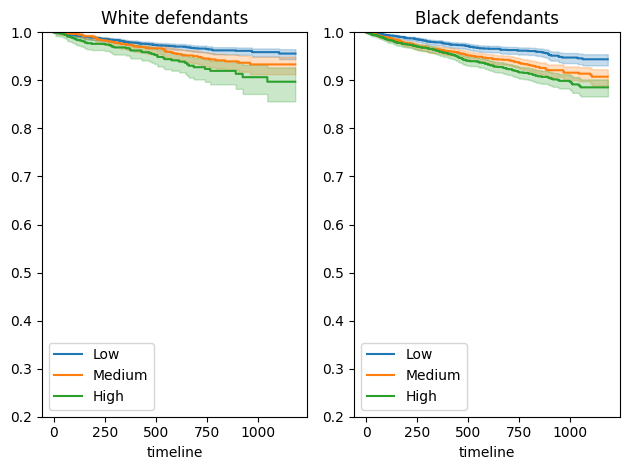

In [125]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = violent_data[violent_data["race"] == "Caucasian"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("White defendants")
axes[0].set_ylim(0.2, 1)

# Black chart
black = violent_data[violent_data["race"] == "African-American"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Black defendants")
axes[1].set_ylim(0.2, 1)

# Show plots
plt.tight_layout()
plt.show()

## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [126]:
import urllib.request

# Download truth_tables.py file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/truth_tables.py",
    "truth_tables.py")

# Download cox-parsed.csv file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv",
    "cox-parsed.csv")

# Import needed classes and functions
from truth_tables import PeekyReader, Person, table, is_race, count, vtable, hightable, vhightable
from csv import DictReader

# Create empty list to store people
people = []

# Read CSV and build Person objects
with open("cox-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

# Keep valid scores and relevant time window
pop = list(filter(
    lambda i: ((i.recidivist == True and i.lifetime <= 730) or i.lifetime > 730),
    list(filter(lambda x: x.score_valid, people))
))

# People who recidivated within 730 days
recid = list(filter(
    lambda i: i.recidivist == True and i.lifetime <= 730,
    pop
))

# Convert recid list to set
rset = set(recid)

# People who did not recidivate within 730 days
surv = [i for i in pop if i not in rset]

We see below that after analysis, 2681 people were correctly labeled Low risk, but 1282 were labeled High risk even though they didn't recidivate (showing overprediction). On the other hand, we see that 2035 were correctly labeled High risk, but 1216 were labeled Low risk even though they did recidivate (underprediction).

The false positive rate shows that about a third of those who did not recidivator were incorrectly labeled high risk, which is indicating overprediction.

The false negative rate shows that 37.40% of recidivators were missed, which is indicating underprediction.

So we see that the model makes both types of errors at fair rates. Further investigation should be conducted to see if subgroups of the data (such as White vs. Black defendants), are causing either error more.

In [127]:
print("All defendants")
#Show the confusion matrix based on the code above
table(list(recid), list(surv))

All defendants
           	Low	High
Survived   	2681	1282	0.55
Recidivated	1216	2035	0.45
Total: 7214.00
False positive rate: 32.35
False negative rate: 37.40
Specificity: 0.68
Sensitivity: 0.63
Prevalence: 0.45
PPV: 0.61
NPV: 0.69
LR+: 1.94
LR-: 0.55


In [128]:
#Show the total population of the confusion matrix
print("Total pop: %i" % (2681 + 1282 + 1216 + 2035))

Total pop: 7214


In [129]:
import statistics
#Print the average follow up time and the medium follow up time
print("Average followup time %.2f (sd %.2f)" % (statistics.mean(map(lambda i: i.lifetime, pop)),
                                                statistics.stdev(map(lambda i: i.lifetime, pop))))
print("Median followup time %i" % (statistics.median(map(lambda i: i.lifetime, pop))))

Average followup time 622.87 (sd 392.19)
Median followup time 766


Overall, the false positive rate is 32.35%. That number is higher for African Americans at 44.85%. On the other hand, the overall false negative rate is 37.40%, and the African American model is less, with a false negative rate of 27.99%. This shows that African Americans are overpredicted in terms of their likelihood of recidivism.

In [130]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Black defendants
           	Low	High
Survived   	990	805	0.49
Recidivated	532	1369	0.51
Total: 3696.00
False positive rate: 44.85
False negative rate: 27.99
Specificity: 0.55
Sensitivity: 0.72
Prevalence: 0.51
PPV: 0.63
NPV: 0.65
LR+: 1.61
LR-: 0.51


In comparison, the false positive rate for White defendants (23.45%) is much les than the overall false positive rate (32.35%). Conversely, the false negative rate for White defendants is 47.72%, which is much higher than the overall false negative rate of 37.40%. This indicates that White defendants are underpredicted in terms of their likelihood of recidivism.

In [131]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

White defendants
           	Low	High
Survived   	1139	349	0.61
Recidivated	461	505	0.39
Total: 2454.00
False positive rate: 23.45
False negative rate: 47.72
Specificity: 0.77
Sensitivity: 0.52
Prevalence: 0.39
PPV: 0.59
NPV: 0.71
LR+: 2.23
LR-: 0.62


Below we see that African Americans are almost twice as likely to be incorrectly labeled as high risk compared to the White defendants, fortifying the evidence that there is overprediction present.

In [132]:
44.85 / 23.45

1.9125799573560769

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [133]:
47.72 / 27.99

1.7048946052161487

Below are confusion matrixes for White and African American defendants who have a High risk score. As we see based on the false positive rates and the false negative rates, African Americans face overprediction (with a higher false positive rate of 15.82% versus 5.44%), and White defendants face underprediction (with a higher false negative rate of 79.81% vs. 61.02%).

For African Americans, the higher false positive rate means they are more likely to be incorrectly labeled as high risk, which can lead to harsher decisions even when they would not reoffend.

For White defendants, the higher false negative rate means they are more likely to be labeled as lower risk when they actually do reoffend, so their risk is being underestimated.

In [134]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

           	Low	High
Survived   	1407	81	0.61
Recidivated	771	195	0.39
Total: 2454.00
False positive rate: 5.44
False negative rate: 79.81
Specificity: 0.95
Sensitivity: 0.20
Prevalence: 0.39
PPV: 0.71
NPV: 0.65
LR+: 3.71
LR-: 0.84


In [135]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

           	Low	High
Survived   	1511	284	0.49
Recidivated	1160	741	0.51
Total: 3696.00
False positive rate: 15.82
False negative rate: 61.02
Specificity: 0.84
Sensitivity: 0.39
Prevalence: 0.51
PPV: 0.72
NPV: 0.57
LR+: 2.46
LR-: 0.72


## Risk of Violent Recidivism

COMPAS also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [136]:
# Download cox-violent-parsed.csv file
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv",
    "cox-violent-parsed.csv")

#Read CSV and build Person objects
vpeople = []
with open("cox-violent-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass
#Keep valid scores and relevant time window
vpop = list(filter(lambda i: ((i.violent_recidivist == True and i.lifetime <= 730) or
                              i.lifetime > 730), list(filter(lambda x: x.vscore_valid, vpeople))))
#People who recidivated within 730 days
vrecid = list(filter(lambda i: i.violent_recidivist == True and i.lifetime <= 730, vpeople))

#Convert recid list to set
vrset = set(vrecid)

#people who did not recidivate within 730 days
vsurv = [i for i in vpop if i not in vrset]

The table below shows how well the violent COMPAS score predicts actual violent recidivism.

The most notable value shown is the PPV of 20%, which indicates that among those who are labeled High risk, only 2 of 10 people actually roffend. Additionally, the false positive rate is 29.73%. This suggests that the model overpredicts violent risk.

In [137]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

All defendants
           	Low	High
Survived   	4121	1597	0.89
Recidivated	347	389	0.11
Total: 6454.00
False positive rate: 27.93
False negative rate: 47.15
Specificity: 0.72
Sensitivity: 0.53
Prevalence: 0.11
PPV: 0.20
NPV: 0.92
LR+: 1.89
LR-: 0.65


When filtering for Black defendants, the false positive rate increases even more, and false negative rate reduces. This indicates that the model is more likely to label Black defendants as high risk, even when they do not recidivate, and also, misses the true recidivators. There is evidence, in this case, of strong overprediction of risk for Black defendants.

In [138]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

Black defendants
           	Low	High
Survived   	1692	1043	0.86
Recidivated	170	273	0.14
Total: 3178.00
False positive rate: 38.14
False negative rate: 38.37
Specificity: 0.62
Sensitivity: 0.62
Prevalence: 0.14
PPV: 0.21
NPV: 0.91
LR+: 1.62
LR-: 0.62


When filtering for White defendants, the false positive rate drops by nearly 20%, and the false negative rate increases by nearly 30%, indicating a strong underprediction of risk for White defendants. This indicates that the model is more likely to label White defendants as low risk, even when they do recidivate.

In [139]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

White defendants
           	Low	High
Survived   	1679	380	0.91
Recidivated	129	77	0.09
Total: 2265.00
False positive rate: 18.46
False negative rate: 62.62
Specificity: 0.82
Sensitivity: 0.37
Prevalence: 0.09
PPV: 0.17
NPV: 0.93
LR+: 2.03
LR-: 0.77


For comparison, we see below that Black defendants are twice as likely to be false positives for a Higher violent score than white defendants. This is an indication of overprediction

In [140]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants, indicating underprediction for White defendants and bias toward Black defendants.

In [141]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

Below, we see confidence levels and estimates from the Kaplan-Meier results when separating the data between women and men. The results show the score is working in the expected direction in both groups, but women have higher survival than men at every score level. For example, at 730 days, High-risk men have a survival of about 0.39, while High-risk women are around 0.53, and even in the Medium group it’s roughly 0.54 vs. 0.66.

Even within the same COMPAS category, women are therefore less likely to recidivate. This suggests that while the score ranks risk similarly across sexes, it may overestimate risk for women relative to men, since women consistently have better outcomes at the same predicted risk level.



In [142]:
from lifelines import KaplanMeierFitter

# Filter data
female = data[data['sex'] == "Female"]
male = data[data['sex'] == "Male"]

# Initialize model
kmf = KaplanMeierFitter()

# Fit for males
male_fit = kmf.fit(durations=male['end'], event_observed=male['event'])

# Fit for females (use a new instance or overwrite safely)
kmf_female = KaplanMeierFitter()
female_fit = kmf_female.fit(durations=female['end'], event_observed=female['event'])

In [143]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["sex"] == "Male"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.7580325690731038
Lower 95% CI: 0.7446590000473494
Upper 95% CI: 0.7708175124728266

Medium
Survival at 730: 0.5352410755610693
Lower 95% CI: 0.5118602776046834
Upper 95% CI: 0.5580250573597276

High
Survival at 730: 0.3880706025064447
Lower 95% CI: 0.3624851213622497
Upper 95% CI: 0.4135618566495568



In [144]:
# Create model
kmf = KaplanMeierFitter()

# Filter to Black defendants
black = data[data["sex"] == "Female"]

# Check each score group at time 730
for score in ["Low", "Medium", "High"]:
    # Filter one group
    subset = black[black["score_factor"] == score]

    # Fit survival curve
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        entry=subset["start"]
    )

    # Get survival at time 730
    survival_730 = kmf.survival_function_at_times(730).values[0]

    # Get confidence interval at time 730
    interval_730 = kmf.confidence_interval_.reindex([730], method="ffill")
    lower_730 = interval_730.iloc[0, 0]
    upper_730 = interval_730.iloc[0, 1]

    # Print results
    print(score)
    print("Survival at 730:", survival_730)
    print("Lower 95% CI:", lower_730)
    print("Upper 95% CI:", upper_730)
    print()

Low
Survival at 730: 0.8380903917405909
Lower 95% CI: 0.8158462339506376
Upper 95% CI: 0.8578855480673137

Medium
Survival at 730: 0.658641020928326
Lower 95% CI: 0.6165139574559965
Upper 95% CI: 0.6973194332387221

High
Survival at 730: 0.5252118679238789
Lower 95% CI: 0.4596005373341131
Upper 95% CI: 0.5865978291411743



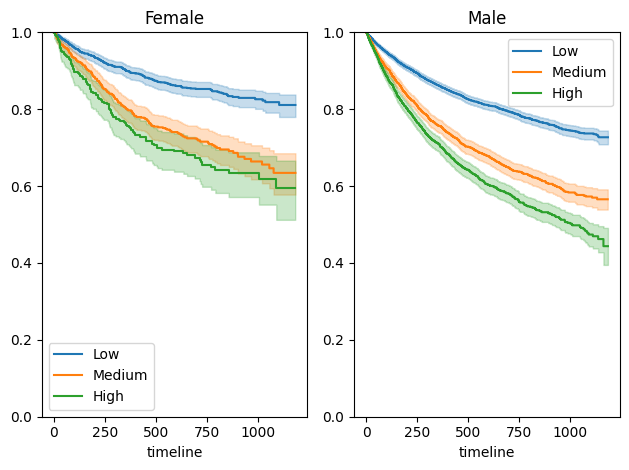

In [145]:
# Create charts
fig, axes = plt.subplots(1, 2)

# White chart
white = data[data["sex"] == "Female"]
for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("Female")
axes[0].set_ylim(0, 1)

# Black chart
black = data[data["sex"] == "Male"]
for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Male")
axes[1].set_ylim(0, 1)

# Show plots
plt.tight_layout()
plt.show()

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.